# ♟️ BrilliantDex
### *Decode Your Chess. Discover Your Brilliance.*

---

**BrilliantDex** is an end-to-end Chess Performance Analytics pipeline built in Python. It takes raw PGN (Portable Game Notation) game data and turns it into structured data, statistical insights, and visual analytics — helping a player understand their strengths, weaknesses, and overall playing style.

This notebook runs through the **entire pipeline**, exactly as designed:

> `PGN Games → Data Validation → PGN Parsing → Data Cleaning → Feature Engineering → EDA → Visualizations → Performance Insights → BrilliantDex Score → Final Dashboard`

**🛠 Tech stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · python-chess · Regex

**📦 What's inside:** 4 of your own Chess.com games are pre-loaded as sample data — just **Run All** and the full pipeline executes top to bottom, ending in a single-screen dashboard and a custom **BrilliantDex Score**.

## 🔧 Step 0 — Setup & Imports

Every library here earns its place: `python-chess` understands chess rules and can replay a game move-by-move, `pandas` / `numpy` handle the structured analysis, `matplotlib` / `seaborn` handle the charts, and `re` (regex) does lightweight text validation before any chess-specific logic runs.

In [1]:
# Installs (safe to re-run -- pip just confirms it's already satisfied if you have these)
import sys
!{sys.executable} -m pip install -q python-chess pandas numpy matplotlib seaborn

import io
import re
import chess
import chess.pgn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline

# --- Notebook-wide chart styling, so every plot shares the BrilliantDex look ---
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Single source of truth for result colors -> reused by every chart below
RESULT_COLORS = {'Win': '#2ecc71', 'Draw': '#f1c40f', 'Loss': '#e74c3c'}

print('Environment ready -- python-chess, pandas, numpy, matplotlib & seaborn loaded.')

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Environment ready -- python-chess, pandas, numpy, matplotlib & seaborn loaded.


## 📥 Step 1 — Import Raw PGN Data

This is the only cell you'd normally touch to re-use the notebook: drop in any list of raw PGN strings and set `USERNAME` to whichever player every downstream stat should be calculated *from the perspective of*. Everything from here on adapts automatically -- no other cell needs to change.

In [2]:
# Your Chess.com / Lichess username -- every "Win/Loss/Draw" and "White vs Black"
# stat in this notebook is calculated from THIS player's perspective. Change it
# to reuse the notebook for a different account.
USERNAME = 'brilliancext'

# Raw PGN text, exactly as exported from Chess.com -- one string per game.
# Add or remove games here; the rest of the pipeline doesn't care how many there are.
raw_pgns = [
    """[Site "Chess.com"][White "Kkpdeep02"][Black "brilliancext"][Result "0-1"][WhiteElo "1083"][BlackElo "1116"][TimeControl "600"]
1. e4 e5 2. d3 Bc5 3. a3 Qf6 4. Be3 d6 5. c3 Bxe3 6. fxe3 Nh6 7. h3 g5 8. Nd2 g4
9. h4 g3 10. Ngf3 Ng4 11. Qa4+ Bd7 12. Qb3 Nxe3 13. Qxb7 Nc2+ 14. Kd1 Nxa1 15.
Qxa8 O-O 16. Qb7 Bg4 17. Qxc7 Nb3 18. Nxb3 Bxf3+ 19. Kd2 Bxg2 20. Rg1 Qf2+ 21.
Be2 Qxg1 22. Qxd6 Qf2 23. Qxe5 Bf3 24. Qg5+ Kh8 25. Qf6+ Kg8 26. Nc1 Nd7 27.
Qg5+ Kh8 28. Qe7 g2 29. Qxd7 g1=Q 30. Qe7 Qe3+ 31. Kc2 Qgxc1+ 32. Kb3 Qb6+ 33.
Ka2 Qcxb2# 0-1""",
    """[Site "Chess.com"][White "Azezel6"][Black "brilliancext"][Result "0-1"][WhiteElo "1091"][BlackElo "1100"][TimeControl "600"]
1. g3 e5 2. Bg2 Bc5 3. d3 Nf6 4. Bg5 Nc6 5. Bxf6 Qxf6 6. e3 Nd4 7. c3 Nf5 8. Nf3
d5 9. b4 Bb6 10. d4 exd4 11. cxd4 O-O 12. Qa4 c6 13. Nc3 Re8 14. b5 Nxe3 15.
fxe3 Rxe3+ 16. Kf2 Rxc3 17. bxc6 Bxd4+ 18. Kf1 Rxf3+ 19. Bxf3 Qxf3+ 20. Ke1
Qxh1+ 21. Kd2 Qxh2+ 22. Kd3 Bxa1 23. cxb7 Bxb7 24. Qd7 Qxg3+ 25. Kc2 Qc3+ 26.
Kd1 Rc8 27. Ke2 Ba6+ 28. Kf2 Qf6+ 29. Ke3 Bd4+ 30. Kd2 Qf2+ 31. Kd1 Qe2# 0-1""",
    """[Site "Chess.com"][White "lovestock"][Black "brilliancext"][Result "0-1"][WhiteElo "1007"][BlackElo "1033"][TimeControl "600"]
1. e4 e5 2. Nf3 Nf6 3. Nc3 Nc6 4. Bb5 Bc5 5. d3 Ng4 6. Be3 Bxe3 7. fxe3 Nxe3 8.
Qd2 Nd4 9. Nxd4 exd4 10. Ne2 Qh4+ 11. g3 Qg5 12. Nf4 Qxb5 13. b3 d6 14. c4 Qb4
15. Qxb4 Nc2+ 16. Kd2 Nxb4 17. a3 Nc6 18. Nd5 Kd7 19. Raf1 f6 20. h4 Ne5 21. Rf4
Kc6 22. Rg1 g5 23. hxg5 fxg5 24. Rf6 Bg4 25. b4 Nf3+ 0-1""",
    """[Site "Chess.com"][White "brilliancext"][Black "Beetrootichigo"][Result "1-0"][WhiteElo "980"][BlackElo "806"][TimeControl "600"]
1. d4 e5 2. e4 d5 3. Nc3 Nc6 4. Nf3 Nf6 5. Be3 Be6 6. Bd3 Bd6 7. O-O O-O 8. Nb5
Nxd4 9. Bxd4 exd4 10. exd5 Bxd5 11. Nxd6 Qxd6 12. Nxd4 Bxa2 13. Rxa2 Qxd4 14.
Bxh7+ Nxh7 15. Qxd4 Ng5 16. Rxa7 Rab8 17. Qa4 Nf3+ 18. gxf3 Ra8 19. Rxa8 Rxa8
20. Qxa8+ Kh7 21. Re1 Kg6 22. h4 Kf5 23. Qa5+ Kf6 24. Re5 g6 25. Qxc7 g5 26.
Rxg5 Ke6 27. Re5+ Kf6 28. Qe7+ Kg7 29. h5 Kh6 30. Qxf7 b5 31. Qf6+ Kh7 32. Re7+
Kg8 33. Qg7# 1-0"""
]

print(f'Loaded {len(raw_pgns)} raw PGN game(s) for player: {USERNAME}')

Loaded 4 raw PGN game(s) for player: brilliancext


## ✅ Step 2 — Data Validation

Before handing anything to a parser, it's worth sanity-checking the raw text itself. This step does two things with **regex**, directly on the raw strings, before any chess-specific logic runs:

1. Confirms every required header tag (`Site`, `White`, `Black`, `Result`, `WhiteElo`, `BlackElo`, `TimeControl`) is present.
2. Confirms the move text ends in a valid PGN result token (`1-0`, `0-1`, `1/2-1/2`, or `*`).

It then catches something validation alone wouldn't: this Chess.com export crams every header onto a single line (`[Site "..."][White "..."]...`) instead of one-per-line. Tested directly, `python-chess` misreads that as one garbled tag -- `White` silently becomes `'?'` and `WhiteElo` becomes `None`. A one-line regex substitution inserts the missing line breaks so Step 3 can parse the games correctly.

In [3]:
def normalize_pgn_headers(pgn_text):
    """
    Chess.com sometimes exports headers all crammed onto a single line:
    [Tag "Val"][Tag "Val"]... Most PGN parsers (including python-chess) expect
    one header per line, so this inserts a newline between adjacent '][' pairs.
    If the headers are already one-per-line, this is a no-op.
    """
    return re.sub(r'\]\[', ']\n[', pgn_text)


def validate_pgn_structure(pgn_text, game_number):
    """
    Lightweight structural validation using regex, run BEFORE python-chess ever
    sees the text. Confirms every required header tag is present somewhere in
    the text, and that the move text ends in a valid PGN result token.
    """
    required_tags = ['Site', 'White', 'Black', 'Result', 'WhiteElo', 'BlackElo', 'TimeControl']
    missing_tags = [tag for tag in required_tags if not re.search(rf'\[{tag}\s+"[^"]*"\]', pgn_text)]

    result_pattern = r'(1-0|0-1|1/2-1/2|\*)\s*$'
    has_valid_result = bool(re.search(result_pattern, pgn_text.strip()))

    is_valid = (len(missing_tags) == 0) and has_valid_result
    status = 'VALID' if is_valid else 'INVALID'
    note = ''
    if missing_tags:
        note += f' | missing tags: {missing_tags}'
    if not has_valid_result:
        note += ' | no result token found'
    print(f'Game {game_number}: {status}{note}')

    return is_valid


print('Running structural validation on all raw games...\n')
validation_results = [validate_pgn_structure(pgn, i + 1) for i, pgn in enumerate(raw_pgns)]
print(f'\n{sum(validation_results)}/{len(validation_results)} games passed validation.')
assert all(validation_results), 'Fix the flagged game(s) above before continuing.'

# All required tags are present and the result token checks out -- but that's
# not the whole story. Handing this text straight to a parser is a different
# test: python-chess reads headers line-by-line, and because every tag here is
# crammed onto ONE line, it actually misreads White as '?' and WhiteElo as None.
# The data has everything it needs; it's just laid out in a way a strict
# line-based parser won't read correctly. One regex substitution fixes it:
normalized_pgns = [normalize_pgn_headers(pgn) for pgn in raw_pgns]

print('\nExample -- before normalization, every header was on one line:')
print(f'  {raw_pgns[0].splitlines()[0][:100]}...')
print('\nAfter normalization, each header gets its own line:')
for line in normalized_pgns[0].splitlines()[:3]:
    print(f'  {line}')

Running structural validation on all raw games...

Game 1: VALID
Game 2: VALID
Game 3: VALID
Game 4: VALID

4/4 games passed validation.

Example -- before normalization, every header was on one line:
  [Site "Chess.com"][White "Kkpdeep02"][Black "brilliancext"][Result "0-1"][WhiteElo "1083"][BlackElo ...

After normalization, each header gets its own line:
  [Site "Chess.com"]
  [White "Kkpdeep02"]
  [Black "brilliancext"]


## ♟️ Step 3 — PGN Parsing

With the text validated and normalized, `python-chess` can now parse each game into a `Game` object -- a full move tree with legal-move awareness, not just a string of text. This means every downstream feature (captures, checks, castling, promotions...) gets computed from real board positions, not regex guesses on the move text.

In [4]:
def parse_pgn_game(pgn_text):
    """Parses one validated, normalized PGN string into a python-chess Game object."""
    pgn_io = io.StringIO(pgn_text)
    game = chess.pgn.read_game(pgn_io)
    if game is None:
        raise ValueError('python-chess could not parse this game -- check the PGN text.')
    return game


parsed_games = [parse_pgn_game(pgn) for pgn in normalized_pgns]

print('Parsed games:\n')
for i, game in enumerate(parsed_games, start=1):
    h = game.headers
    print(f"Game {i}: {h['White']} (W, {h['WhiteElo']}) vs {h['Black']} (B, {h['BlackElo']}) "
          f"-> Result: {h['Result']}")

Parsed games:

Game 1: Kkpdeep02 (W, 1083) vs brilliancext (B, 1116) -> Result: 0-1
Game 2: Azezel6 (W, 1091) vs brilliancext (B, 1100) -> Result: 0-1
Game 3: lovestock (W, 1007) vs brilliancext (B, 1033) -> Result: 0-1
Game 4: brilliancext (W, 980) vs Beetrootichigo (B, 806) -> Result: 1-0


## 🧹 Step 4 — Data Cleaning

`Game.headers` stores *everything* as plain strings, even numbers -- so `'1116'` is a string, not the integer `1116`, and a missing rating would silently break any later `mean()` or `sort_values()` call. This step coerces types properly and applies sane defaults for anything missing, so feature engineering can trust the data it's working with.

In [5]:
def clean_headers(game):
    """
    Cleans and standardizes a Game's header fields:
    - strips stray whitespace from text fields
    - casts Elo ratings to integers (NaN if missing/unrated, instead of crashing)
    - defaults TimeControl to 'Unknown' if missing
    """
    headers = game.headers
    cleaned = {
        'site': headers.get('Site', 'Unknown').strip(),
        'white': headers.get('White', 'Unknown').strip(),
        'black': headers.get('Black', 'Unknown').strip(),
        'result': headers.get('Result', '*').strip(),
        'time_control': headers.get('TimeControl', 'Unknown').strip(),
    }

    for side in ('white', 'black'):
        raw_value = headers.get(f'{side.capitalize()}Elo', None)
        try:
            cleaned[f'{side}_elo'] = int(raw_value)
        except (ValueError, TypeError):
            cleaned[f'{side}_elo'] = np.nan

    return cleaned


cleaned_data = [clean_headers(g) for g in parsed_games]

# Before vs after, on Game 1, to make the type coercion tangible
raw_elo = parsed_games[0].headers.get('WhiteElo')
clean_elo = cleaned_data[0]['white_elo']
print(f'Before cleaning -> WhiteElo: {raw_elo!r} (type: {type(raw_elo).__name__})')
print(f'After cleaning  -> white_elo: {clean_elo!r} (type: {type(clean_elo).__name__})')

Before cleaning -> WhiteElo: '1083' (type: str)
After cleaning  -> white_elo: 1083 (type: int)


## ⚙️ Step 5 — Feature Engineering

This is the heart of the pipeline. For every game, the board is replayed move-by-move using `python-chess`, extracting:

- **Outcome features** -- your result (Win/Draw/Loss), color played, Elo difference vs. the opponent
- **Tactical features** -- total captures, total checks, promotions
- **Structural features** -- total moves, whether the game ended in checkmate, whether/where you castled
- **Opening features** -- the opening sequence (first 3 full moves) and your very first move

Every feature is computed once here and reused by every chart, insight, and score in the rest of the notebook -- change the logic once, and everything downstream stays in sync.

In [6]:
def extract_features(game, cleaned, game_id):
    """Replays a game move-by-move and extracts a row of structured features."""
    board = game.board()
    moves = list(game.mainline_moves())

    captures = 0
    checks = 0
    promotions = 0
    user_castled = False
    castle_side = None

    is_user_white = cleaned['white'].lower() == USERNAME.lower()
    is_user_black = cleaned['black'].lower() == USERNAME.lower()
    user_color = 'White' if is_user_white else ('Black' if is_user_black else 'Unknown')

    for move in moves:
        mover_color = 'White' if board.turn == chess.WHITE else 'Black'

        if board.is_capture(move):
            captures += 1
        if board.is_castling(move) and mover_color == user_color:
            user_castled = True
            castle_side = 'Kingside' if board.is_kingside_castling(move) else 'Queenside'
        if move.promotion is not None:
            promotions += 1

        board.push(move)

        if board.is_check():
            checks += 1

    total_plies = len(moves)
    total_full_moves = (total_plies + 1) // 2

    result = cleaned['result']
    if result == '1-0':
        user_result = 'Win' if is_user_white else 'Loss'
    elif result == '0-1':
        user_result = 'Win' if is_user_black else 'Loss'
    elif result == '1/2-1/2':
        user_result = 'Draw'
    else:
        user_result = 'Unknown'

    user_elo = cleaned['white_elo'] if is_user_white else cleaned['black_elo']
    opponent_elo = cleaned['black_elo'] if is_user_white else cleaned['white_elo']
    opponent_name = cleaned['black'] if is_user_white else cleaned['white']
    elo_diff = (user_elo - opponent_elo) if pd.notna(user_elo) and pd.notna(opponent_elo) else np.nan

    # Opening = first 3 full moves (6 plies), replayed on a fresh board for SAN notation
    opening_board = game.board()
    opening_san = []
    for mv in moves[:6]:
        opening_san.append(opening_board.san(mv))
        opening_board.push(mv)

    return {
        'game_id': game_id,
        'white_player': cleaned['white'],
        'black_player': cleaned['black'],
        'opponent': opponent_name,
        'time_control': cleaned['time_control'],
        'user_color': user_color,
        'user_elo': user_elo,
        'opponent_elo': opponent_elo,
        'elo_diff': elo_diff,
        'user_result': user_result,
        'total_full_moves': total_full_moves,
        'total_plies': total_plies,
        'ended_in_checkmate': board.is_checkmate(),
        'total_captures': captures,
        'total_checks': checks,
        'total_promotions': promotions,
        'user_castled': user_castled,
        'castle_side': castle_side,
        'opening_moves': ' '.join(opening_san),
        'first_move': opening_san[0] if opening_san else None,
    }


features = [extract_features(g, c, i + 1) for i, (g, c) in enumerate(zip(parsed_games, cleaned_data))]
df = pd.DataFrame(features)

print(f'Feature table built: {df.shape[0]} games x {df.shape[1]} features\n')
display(df)

Feature table built: 4 games x 20 features



,game_id,white_player,black_player,opponent,time_control,user_color,user_elo,opponent_elo,elo_diff,user_result,total_full_moves,total_plies,ended_in_checkmate,total_captures,total_checks,total_promotions,user_castled,castle_side,opening_moves,first_move
0,1,Kkpdeep02,brilliancext,Kkpdeep02,600,Black,1116,1083,33,Win,33,66,True,16,11,1,True,Kingside,e4 e5 d3 Bc5 a3 Qf6,e4
1,2,Azezel6,brilliancext,Azezel6,600,Black,1100,1091,9,Win,31,62,True,19,13,0,True,Kingside,g3 e5 Bg2 Bc5 d3 Nf6,g3
2,3,lovestock,brilliancext,lovestock,600,Black,1033,1007,26,Win,25,50,False,10,3,0,False,NaN,e4 e5 Nf3 Nf6 Nc3 Nc6,e4
3,4,brilliancext,Beetrootichigo,Beetrootichigo,600,White,980,806,174,Win,33,65,True,22,9,0,True,Kingside,d4 e5 e4 d5 Nc3 Nc6,d4


## 📊 Step 6 — Exploratory Data Analysis (EDA)

A quick statistical pass over the feature table before moving to charts -- shape, types, summary statistics, and the basic result/color breakdowns everything else builds on.

In [7]:
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n')

print('Column types:')
print(df.dtypes)

print('\nSummary statistics (numeric columns):')
display(df[['user_elo', 'opponent_elo', 'elo_diff', 'total_full_moves',
            'total_captures', 'total_checks']].describe())

print('\nResult breakdown:')
print(df['user_result'].value_counts())

print('\nColor breakdown:')
print(df['user_color'].value_counts())

Dataset shape: 4 rows x 20 columns

Column types:
game_id               int64
white_player            str
black_player            str
opponent                str
time_control            str
user_color              str
user_elo              int64
opponent_elo          int64
elo_diff              int64
user_result             str
total_full_moves      int64
total_plies           int64
ended_in_checkmate     bool
total_captures        int64
total_checks          int64
total_promotions      int64
user_castled           bool
castle_side             str
opening_moves           str
first_move              str
dtype: object

Summary statistics (numeric columns):


,user_elo,opponent_elo,elo_diff,total_full_moves,total_captures,total_checks
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,1057.250000,996.750000,60.500000,30.500000,16.750000,9.000000
std,62.808572,132.681008,76.334789,3.785939,5.123475,4.320494
min,980.000000,806.000000,9.000000,25.000000,10.000000,3.000000
25%,1019.750000,956.750000,21.750000,29.500000,14.500000,7.500000
50%,1066.500000,1045.000000,29.500000,32.000000,17.500000,10.000000
75%,1104.000000,1085.000000,68.250000,33.000000,19.750000,11.500000
max,1116.000000,1091.000000,174.000000,33.000000,22.000000,13.000000



Result breakdown:
user_result
Win    4
Name: count, dtype: int64

Color breakdown:
user_color
Black    3
White    1
Name: count, dtype: int64


## 📈 Step 7 — Visualizations

Six charts, each isolating one angle on the same feature table: the overall record, color split, Elo edge, game length, tactical activity, and how Elo difference relates to game length.

> ⚠️ Heads up: this batch is only 4 games, and all 4 are wins -- so the Win/Draw/Loss pie and the color-comparison chart won't show much variation *yet*. Both are built to scale automatically once games with a draw or a loss get added in Step 1. The real signal in this batch is in the Elo-edge, game-length, and tactical-activity charts.

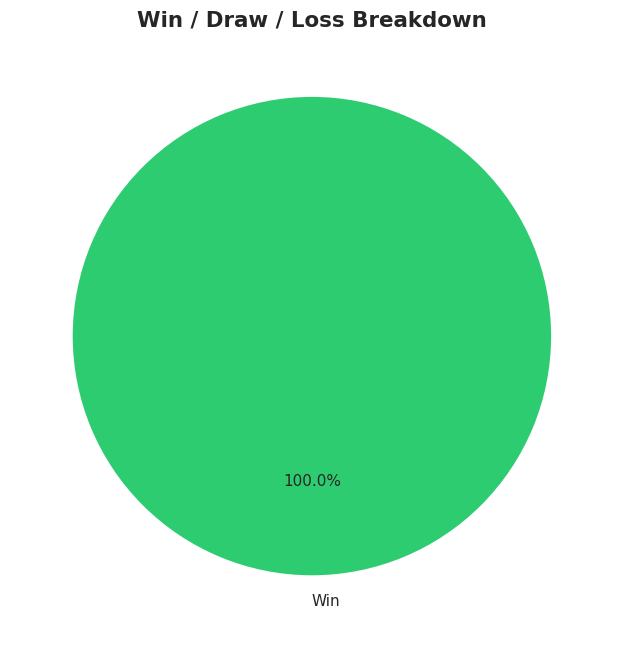

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

result_counts = df['user_result'].value_counts()
slice_colors = [RESULT_COLORS.get(r, '#95a5a6') for r in result_counts.index]

ax.pie(result_counts.values, labels=result_counts.index, autopct='%1.1f%%',
       colors=slice_colors, startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Win / Draw / Loss Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

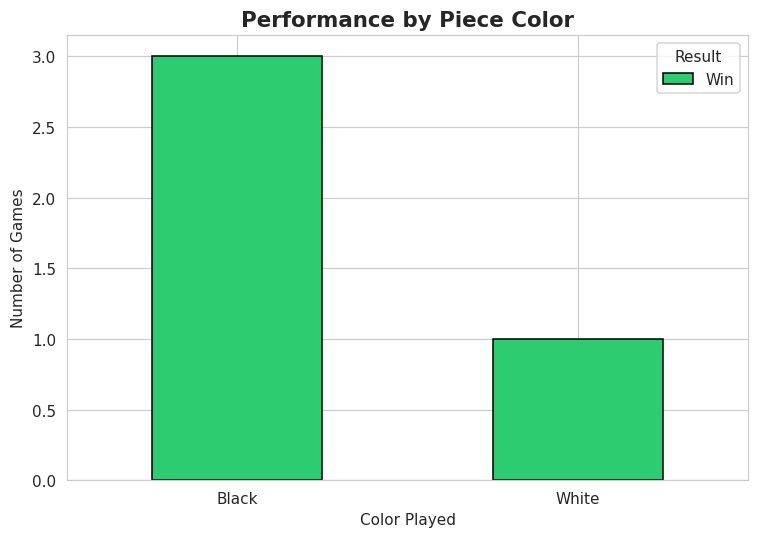

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

color_result = pd.crosstab(df['user_color'], df['user_result'])
color_result = color_result.reindex(columns=[c for c in RESULT_COLORS if c in color_result.columns])
color_result.plot(kind='bar', stacked=True, ax=ax,
                   color=[RESULT_COLORS[c] for c in color_result.columns],
                   edgecolor='black')

ax.set_title('Performance by Piece Color', fontsize=14, fontweight='bold')
ax.set_xlabel('Color Played')
ax.set_ylabel('Number of Games')
ax.legend(title='Result')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

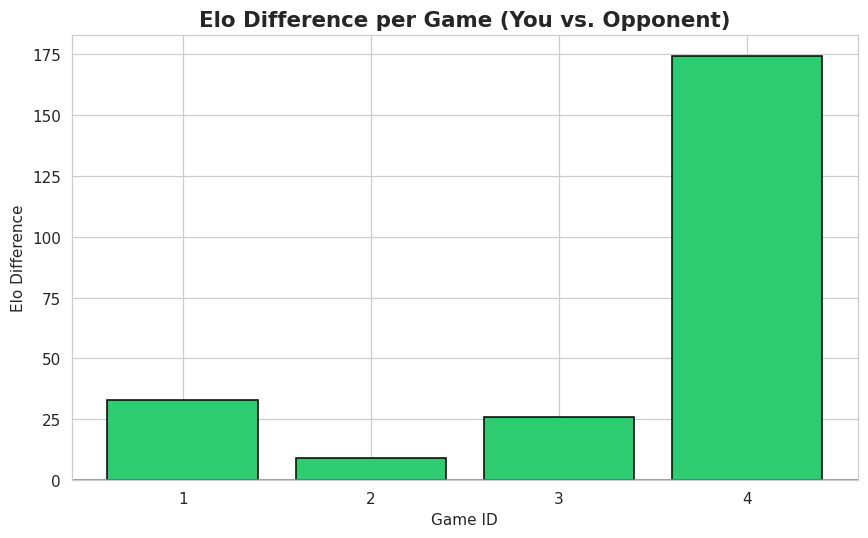

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [RESULT_COLORS.get(r, '#95a5a6') for r in df['user_result']]
ax.bar(df['game_id'], df['elo_diff'], color=bar_colors, edgecolor='black')
ax.axhline(0, color='gray', linewidth=1)

ax.set_title('Elo Difference per Game (You vs. Opponent)', fontsize=14, fontweight='bold')
ax.set_xlabel('Game ID')
ax.set_ylabel('Elo Difference')
ax.set_xticks(df['game_id'])
plt.tight_layout()
plt.show()

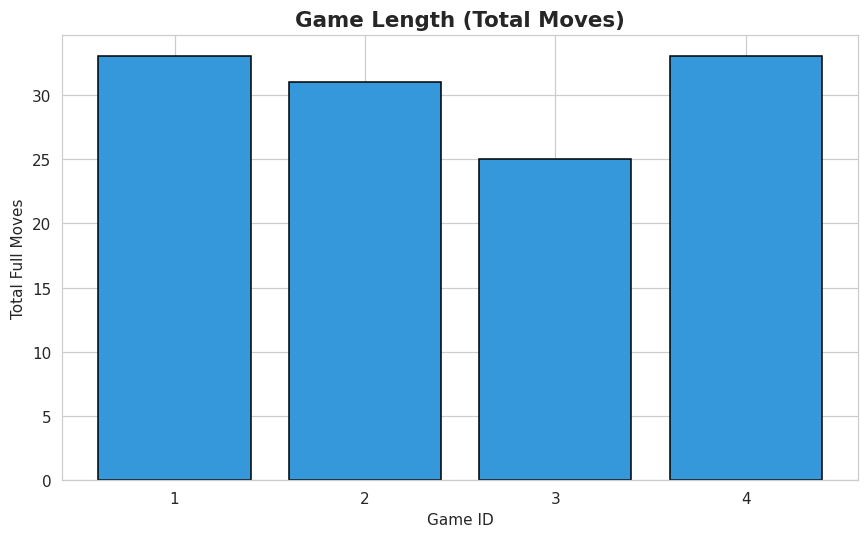

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(df['game_id'], df['total_full_moves'], color='#3498db', edgecolor='black')

ax.set_title('Game Length (Total Moves)', fontsize=14, fontweight='bold')
ax.set_xlabel('Game ID')
ax.set_ylabel('Total Full Moves')
ax.set_xticks(df['game_id'])
plt.tight_layout()
plt.show()

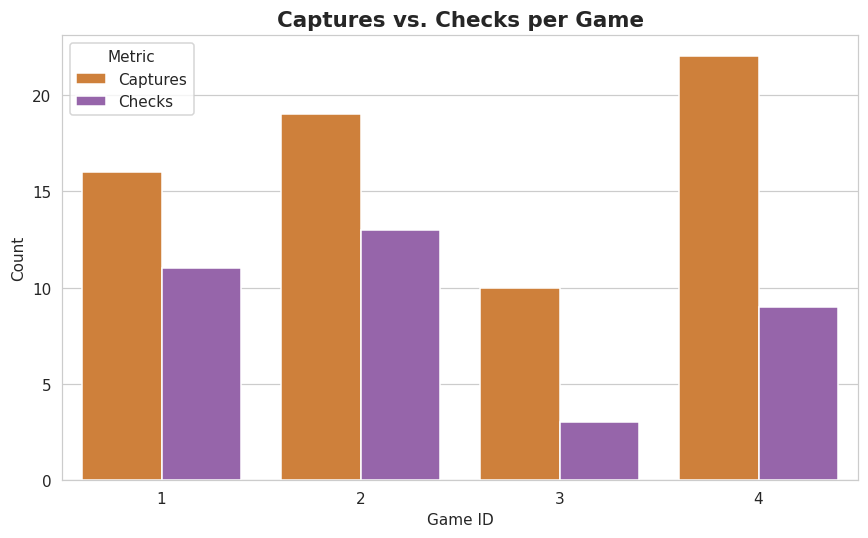

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = df.melt(id_vars='game_id', value_vars=['total_captures', 'total_checks'],
                   var_name='Metric', value_name='Count')
plot_df['Metric'] = plot_df['Metric'].map({'total_captures': 'Captures', 'total_checks': 'Checks'})

sns.barplot(data=plot_df, x='game_id', y='Count', hue='Metric', ax=ax,
            palette={'Captures': '#e67e22', 'Checks': '#9b59b6'})

ax.set_title('Captures vs. Checks per Game', fontsize=14, fontweight='bold')
ax.set_xlabel('Game ID')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

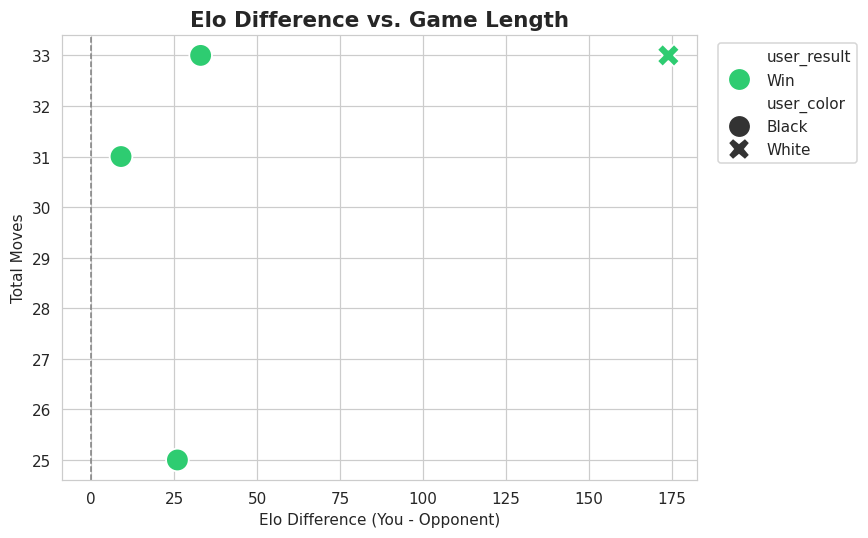

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x='elo_diff', y='total_full_moves', hue='user_result',
                 style='user_color', s=220, palette=RESULT_COLORS, ax=ax)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Elo Difference vs. Game Length', fontsize=14, fontweight='bold')
ax.set_xlabel('Elo Difference (You - Opponent)')
ax.set_ylabel('Total Moves')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 🧠 Step 8 — Performance Insights

Turning the charts above into plain-English takeaways -- automatically generated from the feature table, so they stay accurate as more games get added.

In [14]:
wins = (df['user_result'] == 'Win').sum()
draws = (df['user_result'] == 'Draw').sum()
losses = (df['user_result'] == 'Loss').sum()
total_games = len(df)

print(f'Overall record: {wins}W - {draws}D - {losses}L across {total_games} games')
print(f'Win rate: {(wins / total_games) * 100:.1f}%')

white_games = df[df['user_color'] == 'White']
black_games = df[df['user_color'] == 'Black']

if len(white_games) > 0:
    print(f"As White: {len(white_games)} game(s), "
          f"{(white_games['user_result'] == 'Win').mean() * 100:.1f}% win rate")
if len(black_games) > 0:
    print(f"As Black: {len(black_games)} game(s), "
          f"{(black_games['user_result'] == 'Win').mean() * 100:.1f}% win rate")

print(f"Average opponent Elo faced: {df['opponent_elo'].mean():.0f}")

wins_df = df[df['user_result'] == 'Win']
if len(wins_df) > 0:
    closest = wins_df.loc[wins_df['elo_diff'].idxmin()]
    if closest['elo_diff'] < 0:
        print(f"Biggest upset: beat {closest['opponent']} (Elo {closest['opponent_elo']:.0f}) "
              f"while rated {abs(closest['elo_diff']):.0f} points lower (Game {closest['game_id']})")
    else:
        print(f"Toughest test on paper: beat {closest['opponent']} (Elo {closest['opponent_elo']:.0f}), "
              f"the smallest rating edge in this batch at +{closest['elo_diff']:.0f} (Game {closest['game_id']})")

most_tactical = df.loc[(df['total_captures'] + df['total_checks']).idxmax()]
print(f"Most tactical game: Game {most_tactical['game_id']} vs {most_tactical['opponent']} "
      f"({most_tactical['total_captures']} captures, {most_tactical['total_checks']} checks)")

longest = df.loc[df['total_full_moves'].idxmax()]
shortest = df.loc[df['total_full_moves'].idxmin()]
print(f"Longest game: Game {longest['game_id']} ({longest['total_full_moves']} moves vs {longest['opponent']})")
print(f"Shortest game: Game {shortest['game_id']} ({shortest['total_full_moves']} moves vs {shortest['opponent']})")

mate_finishes = df['ended_in_checkmate'].sum()
print(f"Checkmate finishes: {mate_finishes}/{total_games} games ended in a delivered checkmate")

castled_games = df['user_castled'].sum()
print(f"Castled in {castled_games}/{total_games} games")

Overall record: 4W - 0D - 0L across 4 games
Win rate: 100.0%
As White: 1 game(s), 100.0% win rate
As Black: 3 game(s), 100.0% win rate
Average opponent Elo faced: 997
Toughest test on paper: beat Azezel6 (Elo 1091), the smallest rating edge in this batch at +9 (Game 2)
Most tactical game: Game 2 vs Azezel6 (19 captures, 13 checks)
Longest game: Game 1 (33 moves vs Kkpdeep02)
Shortest game: Game 3 (25 moves vs lovestock)
Checkmate finishes: 3/4 games ended in a delivered checkmate
Castled in 3/4 games


## 🏆 Step 9 — BrilliantDex Performance Score

A single composite number (0-100) summarizing the games above, built from four sub-scores:

| Sub-score | What it rewards | Weight |
|---|---|---|
| **Win Rate** | Simply: how often you won | 35% |
| **Clutch Factor** | Outperforming what your Elo "should" score, using the standard chess Elo expected-score formula | 30% |
| **Finishing Power** | Ending games with a delivered checkmate, not just a resignation | 20% |
| **Aggression Index** | Tactical density -- checks + captures relative to game length | 15% |

The weights live in a single `WEIGHTS` dict below -- tune them to whatever "brilliance" should mean to you.

In [15]:
def expected_score(user_elo, opponent_elo):
    """Standard Elo expected-score formula: P(win) given the rating gap."""
    if pd.isna(user_elo) or pd.isna(opponent_elo):
        return np.nan
    return 1 / (1 + 10 ** ((opponent_elo - user_elo) / 400))


def actual_score(user_result):
    return {'Win': 1.0, 'Draw': 0.5, 'Loss': 0.0}.get(user_result, np.nan)


df['expected_score'] = df.apply(lambda r: expected_score(r['user_elo'], r['opponent_elo']), axis=1)
df['actual_score'] = df['user_result'].apply(actual_score)
df['performance_diff'] = df['actual_score'] - df['expected_score']
df['aggression_ratio'] = (df['total_checks'] + df['total_captures']) / df['total_full_moves']

win_rate_score = (df['user_result'] == 'Win').mean() * 100
clutch_factor = np.clip(50 + (df['performance_diff'].mean() * 100), 0, 100)
finishing_power = (df['ended_in_checkmate'].sum() / len(df)) * 100
aggression_index = np.clip(df['aggression_ratio'].mean() * 100, 0, 100)

WEIGHTS = {'win_rate': 0.35, 'clutch': 0.30, 'finishing': 0.20, 'aggression': 0.15}

brilliantdex_score = (
    win_rate_score * WEIGHTS['win_rate'] +
    clutch_factor * WEIGHTS['clutch'] +
    finishing_power * WEIGHTS['finishing'] +
    aggression_index * WEIGHTS['aggression']
)

print(f'Win Rate Score      : {win_rate_score:5.1f} / 100')
print(f'Clutch Factor       : {clutch_factor:5.1f} / 100')
print(f'Finishing Power     : {finishing_power:5.1f} / 100')
print(f'Aggression Index    : {aggression_index:5.1f} / 100')
print('-' * 38)
print(f'BRILLIANTDEX SCORE  : {brilliantdex_score:5.1f} / 100')

Win Rate Score      : 100.0 / 100
Clutch Factor       :  91.8 / 100
Finishing Power     :  75.0 / 100
Aggression Index    :  82.7 / 100
--------------------------------------
BRILLIANTDEX SCORE  :  89.9 / 100


## 🖥️ Step 10 — Final Dashboard

Everything above, compressed onto one screen -- the kind of single image you'd actually screenshot and share.

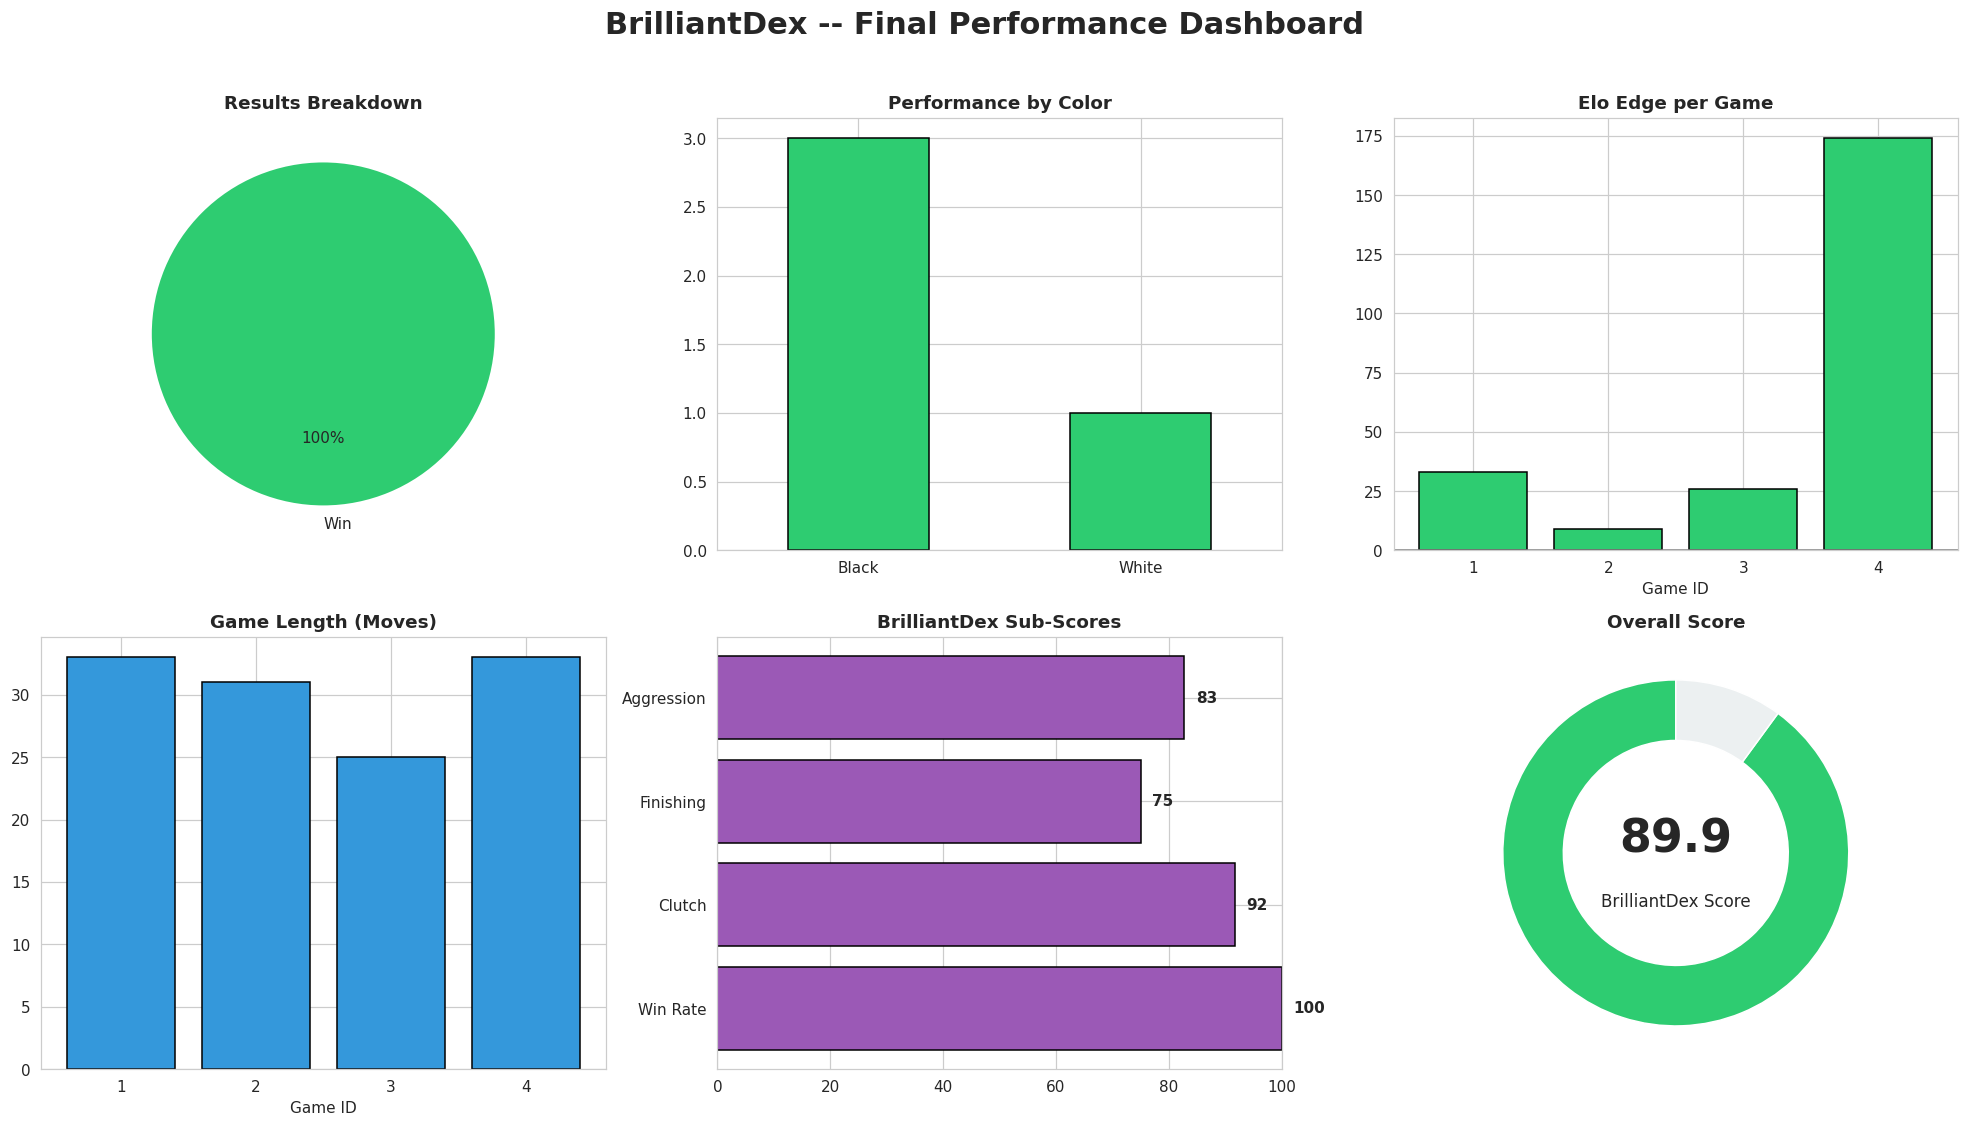


Dashboard saved as 'brilliantdex_dashboard.png'


In [16]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('BrilliantDex -- Final Performance Dashboard', fontsize=20, fontweight='bold', y=1.02)

# Panel 1: Results pie
ax1 = plt.subplot(2, 3, 1)
result_counts = df['user_result'].value_counts()
ax1.pie(result_counts.values, labels=result_counts.index, autopct='%1.0f%%',
        colors=[RESULT_COLORS.get(r, '#95a5a6') for r in result_counts.index],
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Results Breakdown', fontweight='bold')

# Panel 2: Performance by color
ax2 = plt.subplot(2, 3, 2)
color_result = pd.crosstab(df['user_color'], df['user_result'])
color_result = color_result.reindex(columns=[c for c in RESULT_COLORS if c in color_result.columns])
color_result.plot(kind='bar', stacked=True, ax=ax2,
                   color=[RESULT_COLORS[c] for c in color_result.columns],
                   edgecolor='black', legend=False)
ax2.set_title('Performance by Color', fontweight='bold')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)

# Panel 3: Elo edge
ax3 = plt.subplot(2, 3, 3)
bar_colors = [RESULT_COLORS.get(r, '#95a5a6') for r in df['user_result']]
ax3.bar(df['game_id'], df['elo_diff'], color=bar_colors, edgecolor='black')
ax3.axhline(0, color='gray', linewidth=1)
ax3.set_title('Elo Edge per Game', fontweight='bold')
ax3.set_xlabel('Game ID')
ax3.set_xticks(df['game_id'])

# Panel 4: Game length
ax4 = plt.subplot(2, 3, 4)
ax4.bar(df['game_id'], df['total_full_moves'], color='#3498db', edgecolor='black')
ax4.set_title('Game Length (Moves)', fontweight='bold')
ax4.set_xlabel('Game ID')
ax4.set_xticks(df['game_id'])

# Panel 5: BrilliantDex sub-scores
ax5 = plt.subplot(2, 3, 5)
sub_scores = {
    'Win Rate': win_rate_score,
    'Clutch': clutch_factor,
    'Finishing': finishing_power,
    'Aggression': aggression_index,
}
bars = ax5.barh(list(sub_scores.keys()), list(sub_scores.values()), color='#9b59b6', edgecolor='black')
ax5.set_xlim(0, 100)
ax5.set_title('BrilliantDex Sub-Scores', fontweight='bold')
for bar, value in zip(bars, sub_scores.values()):
    ax5.text(value + 2, bar.get_y() + bar.get_height() / 2, f'{value:.0f}',
              va='center', fontweight='bold')

# Panel 6: Final score donut
ax6 = plt.subplot(2, 3, 6)
ax6.pie([brilliantdex_score, 100 - brilliantdex_score],
        colors=['#2ecc71', '#ecf0f1'], startangle=90,
        wedgeprops={'width': 0.35, 'edgecolor': 'white'})
ax6.text(0, 0.08, f'{brilliantdex_score:.1f}', ha='center', va='center',
          fontsize=30, fontweight='bold')
ax6.text(0, -0.28, 'BrilliantDex Score', ha='center', va='center', fontsize=11)
ax6.set_title('Overall Score', fontweight='bold')

plt.tight_layout()
plt.savefig('brilliantdex_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDashboard saved as 'brilliantdex_dashboard.png'")

In [17]:
print(f'This run analyzed {len(df)} games end-to-end.')
print(f'Final BrilliantDex Score: {brilliantdex_score:.1f} / 100')

This run analyzed 4 games end-to-end.
Final BrilliantDex Score: 89.9 / 100


## 🎯 Next Steps

Ideas for extending this pipeline further:

- Pull games automatically via the Chess.com or Lichess public APIs instead of pasting PGNs by hand.
- Classify openings properly using an ECO code lookup table instead of just the first 3 moves.
- Track Elo and BrilliantDex Score *over time* as a line chart, once there's a longer game history.
- Add per-piece activity tracking -- which piece delivers the most checks/captures -- a natural fit alongside the bishop-tactics content.
- Wrap this into a small Streamlit app so the dashboard updates live as new games are added.

---

*Built with BrilliantDex -- Decode Your Chess. Discover Your Brilliance. ♟*

In [ ]:
# ============================================================
# 📄 BONUS CELL -- Generate the BrilliantDex PDF Report
# ============================================================
# Builds a 7-page polished PDF: Cover + About + Tech Stack +
# Methodology + BrilliantDex Score + Insights + How To Run.
# Embeds the dashboard PNG you already generated above. 🎯
# Output: BrilliantDex_README.pdf (in this same folder)
# ============================================================

# -- install reportlab if not already there
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'reportlab', '-q', '--break-system-packages'], check=True)

from reportlab.platypus import (
    BaseDocTemplate, PageTemplate, Frame, NextPageTemplate, PageBreak,
    Paragraph, Spacer, Table, TableStyle, Image, KeepTogether, Flowable
)
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
import os

# -- register DejaVu Sans for chess unicode glyphs (Helvetica renders them as black boxes)
DEJAVU_PATH = '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'
DEJAVU_BOLD_PATH = '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf'
if os.path.exists(DEJAVU_PATH):
    pdfmetrics.registerFont(TTFont('DejaVuSans', DEJAVU_PATH))
    pdfmetrics.registerFont(TTFont('DejaVuSans-Bold', DEJAVU_BOLD_PATH))
    GLYPH_FONT = 'DejaVuSans'
    GLYPH_FONT_BOLD = 'DejaVuSans-Bold'
else:
    # fallback: no chess glyphs, Helvetica only
    GLYPH_FONT = 'Helvetica'
    GLYPH_FONT_BOLD = 'Helvetica-Bold'
    print("⚠️  DejaVu fonts not found -- chess glyphs may not render. PDF will still build.")

# ------------------------------------------------------------------
# 🎨 Palette
# ------------------------------------------------------------------
NAVY       = colors.HexColor('#1a1a2e')
NAVY_LIGHT = colors.HexColor('#23233c')
GOLD       = colors.HexColor('#d4af37')
GOLD_LIGHT = colors.HexColor('#f1c40f')
GREEN      = colors.HexColor('#2ecc71')
CREAM_BG   = colors.HexColor('#fbf3da')
ALT_ROW    = colors.HexColor('#f5f2ea')
DARK_TEXT  = colors.HexColor('#2b2b33')
GRAY_TEXT  = colors.HexColor('#6e6e7a')
BORDER_GRAY = colors.HexColor('#dcdcdc')

# ------------------------------------------------------------------
# 📐 Page geometry
# ------------------------------------------------------------------
PAGE_W, PAGE_H = letter
MARGIN_L = MARGIN_R = 0.65 * inch
MARGIN_T = MARGIN_B = 0.78 * inch
CONTENT_W = PAGE_W - MARGIN_L - MARGIN_R

# dashboard image path -- same folder as this notebook
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
DASH_PATH = os.path.join(NOTEBOOK_DIR, 'brilliantdex_dashboard.png')
PDF_PATH  = os.path.join(NOTEBOOK_DIR, 'BrilliantDex_README.pdf')
DASH_ASPECT = 2685 / 1536  # confirmed pixel dims

# ------------------------------------------------------------------
# 📝 Paragraph styles
# ------------------------------------------------------------------
P_BODY      = ParagraphStyle('Body',      fontName='Helvetica',       fontSize=10.3, leading=15.5, textColor=DARK_TEXT, spaceAfter=8, alignment=TA_JUSTIFY)
P_BULLET    = ParagraphStyle('Bullet',    fontName='Helvetica',       fontSize=10.2, leading=14.5, textColor=DARK_TEXT, spaceAfter=6, leftIndent=4)
P_SECTION   = ParagraphStyle('Section',  fontName='Helvetica-Bold',   fontSize=12.8, leading=16, textColor=NAVY, spaceBefore=12, spaceAfter=7)
P_SUBSECTION= ParagraphStyle('SubSect',  fontName='Helvetica-Bold',   fontSize=10.8, leading=14, textColor=NAVY, spaceBefore=2, spaceAfter=4)
P_CAPTION   = ParagraphStyle('Caption',  fontName='Helvetica-Oblique',fontSize=8.5, leading=11, textColor=GRAY_TEXT, alignment=TA_CENTER, spaceBefore=5)
P_HEADERBAR = ParagraphStyle('HeaderBar',fontName='Helvetica-Bold',   fontSize=15.5, leading=18, textColor=colors.white)
P_CELL      = ParagraphStyle('Cell',     fontName='Helvetica',        fontSize=9, leading=12, textColor=DARK_TEXT)
P_CELL_B    = ParagraphStyle('CellB',    fontName='Helvetica-Bold',   fontSize=9, leading=12, textColor=DARK_TEXT)
P_CELL_C    = ParagraphStyle('CellC',    fontName='Helvetica',        fontSize=9, leading=12, textColor=DARK_TEXT, alignment=TA_CENTER)
P_THEAD     = ParagraphStyle('THead',    fontName='Helvetica-Bold',   fontSize=9.3, leading=12, textColor=colors.white, alignment=TA_CENTER)
P_SNAP_LABEL= ParagraphStyle('SnapL',   fontName='Helvetica-Bold',   fontSize=9.5, leading=13, textColor=NAVY)
P_SNAP_VALUE= ParagraphStyle('SnapV',   fontName='Helvetica',        fontSize=9.5, leading=13, textColor=DARK_TEXT)

def hb(text, icon=None):
    """Navy header bar with optional chess unicode icon."""
    s = f'<font name="{GLYPH_FONT_BOLD}">{icon}</font>  {text}' if icon else text
    t = Table([[Paragraph(s, P_HEADERBAR)]], colWidths=[CONTENT_W])
    t.setStyle(TableStyle([
        ('BACKGROUND', (0,0),(-1,-1), NAVY),
        ('TOPPADDING', (0,0),(-1,-1), 9), ('BOTTOMPADDING',(0,0),(-1,-1), 9),
        ('LEFTPADDING',(0,0),(-1,-1), 14), ('VALIGN',(0,0),(-1,-1),'MIDDLE'),
    ]))
    return t

def bullet(text):
    return Paragraph(f'<font color="#d4af37">&#8226;</font>  {text}', P_BULLET)

# ------------------------------------------------------------------
# 🔷 Workflow diagram flowable
# ------------------------------------------------------------------
class WorkflowDiagram(Flowable):
    def __init__(self, steps, width, box_height=25, gap=13, box_width_ratio=0.66):
        Flowable.__init__(self)
        self.steps = steps; self.width = width
        self.box_height = box_height; self.gap = gap
        self.box_width = width * box_width_ratio; self.n = len(steps)
        self.height = self.n * box_height + (self.n - 1) * gap

    def wrap(self, aw, ah): return (self.width, self.height)

    def draw(self):
        c = self.canv
        box_x = (self.width - self.box_width) / 2
        y = self.height - self.box_height
        for i, step in enumerate(self.steps):
            is_navy = (i % 2 == 0)
            c.setFillColor(NAVY if is_navy else GOLD)
            c.roundRect(box_x, y, self.box_width, self.box_height, 4, fill=1, stroke=0)
            c.setFillColor(colors.white if is_navy else NAVY)
            c.setFont('Helvetica-Bold', 9.5)
            c.drawCentredString(self.width / 2, y + self.box_height / 2 - 3.3, step)
            if i < self.n - 1:
                cx = self.width / 2
                top = y - 1; bottom = y - self.gap + 4
                c.setStrokeColor(GOLD if is_navy else NAVY); c.setLineWidth(1.5)
                c.line(cx, top, cx, bottom)
                c.setFillColor(GOLD if is_navy else NAVY)
                p = c.beginPath()
                p.moveTo(cx - 3.5, bottom); p.lineTo(cx + 3.5, bottom); p.lineTo(cx, bottom - 5); p.close()
                c.drawPath(p, fill=1, stroke=0)
            y -= (self.box_height + self.gap)

# ------------------------------------------------------------------
# 🎨 Cover page (full-bleed navy, hand-drawn on canvas)
# ------------------------------------------------------------------
def draw_cover(canv, doc):
    canv.saveState()
    canv.setFillColor(NAVY); canv.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
    canv.setStrokeColor(GOLD); canv.setLineWidth(1.3)
    canv.line(1*inch, PAGE_H-1.55*inch, PAGE_W-1*inch, PAGE_H-1.55*inch)
    canv.setFont(GLYPH_FONT, 21); canv.setFillColor(GOLD)
    canv.drawCentredString(PAGE_W/2, PAGE_H-2.05*inch, '\u265F \u265E \u265D \u265C \u265B \u265A')
    canv.setFont(GLYPH_FONT_BOLD, 44); canv.setFillColor(GOLD)
    canv.drawCentredString(PAGE_W/2, PAGE_H-3.15*inch, 'BrilliantDex')
    canv.setFont('Helvetica-Oblique', 13.5); canv.setFillColor(colors.white)
    canv.drawCentredString(PAGE_W/2, PAGE_H-3.58*inch, 'Decode Your Chess. Discover Your Brilliance.')
    canv.setFont('Helvetica', 10.5); canv.setFillColor(colors.HexColor('#b8b8c8'))
    canv.drawCentredString(PAGE_W/2, PAGE_H-3.88*inch, 'PROJECT DOCUMENTATION  &  PERFORMANCE INSIGHTS')
    canv.setStrokeColor(GOLD); canv.setLineWidth(1.3)
    canv.line(1*inch, PAGE_H-4.25*inch, PAGE_W-1*inch, PAGE_H-4.25*inch)
    # stat strip
    bx, by, bw, bh = 1*inch, PAGE_H-6.45*inch, PAGE_W-2*inch, 1.7*inch
    canv.setFillColor(NAVY_LIGHT); canv.roundRect(bx, by, bw, bh, 8, fill=1, stroke=0)
    stats = [('4 \u2013 0','RECORD'),('100%','WIN RATE'),('89.9','BRILLIANTDEX SCORE'),('997','AVG. OPP. ELO')]
    cw = bw / len(stats)
    for i, (val, lbl) in enumerate(stats):
        cx = bx + cw*i + cw/2
        canv.setFont('Helvetica-Bold', 23)
        canv.setFillColor(GOLD_LIGHT if i == 2 else GOLD)
        canv.drawCentredString(cx, by + bh*0.56, val)
        canv.setFont('Helvetica', 7.8); canv.setFillColor(colors.HexColor('#cfcfe0'))
        canv.drawCentredString(cx, by + bh*0.27, lbl)
        if i > 0:
            canv.setStrokeColor(colors.HexColor('#3c3c58')); canv.setLineWidth(0.6)
            canv.line(bx+cw*i, by+bh*0.15, bx+cw*i, by+bh*0.85)
    canv.setFont('Helvetica', 9.3); canv.setFillColor(colors.HexColor('#9090a8'))
    canv.drawCentredString(PAGE_W/2, 0.95*inch, 'Player: brilliancext  \u00b7  Chess.com  \u00b7  4 Games Analyzed  \u00b7  10-Min Rapid')
    canv.setFont('Helvetica', 8.6)
    canv.drawCentredString(PAGE_W/2, 0.72*inch, 'Built with Python \u00b7 Pandas \u00b7 NumPy \u00b7 Matplotlib \u00b7 Seaborn \u00b7 python-chess \u00b7 Regex')
    canv.restoreState()

def draw_content_page(canv, doc):
    canv.saveState()
    canv.setStrokeColor(GOLD); canv.setLineWidth(2)
    canv.line(MARGIN_L, PAGE_H-0.52*inch, PAGE_W-MARGIN_R, PAGE_H-0.52*inch)
    canv.setFont('Helvetica-Bold', 8.5); canv.setFillColor(NAVY)
    canv.drawString(MARGIN_L, PAGE_H-0.43*inch, 'BRILLIANTDEX')
    canv.setFont('Helvetica', 8.5); canv.setFillColor(GRAY_TEXT)
    canv.drawRightString(PAGE_W-MARGIN_R, PAGE_H-0.43*inch, 'Chess Performance Analytics')
    canv.setStrokeColor(BORDER_GRAY); canv.setLineWidth(0.75)
    canv.line(MARGIN_L, 0.58*inch, PAGE_W-MARGIN_R, 0.58*inch)
    canv.setFont('Helvetica', 8); canv.setFillColor(GRAY_TEXT)
    canv.drawString(MARGIN_L, 0.40*inch, 'BrilliantDex \u00b7 Decode Your Chess. Discover Your Brilliance.')
    canv.drawRightString(PAGE_W-MARGIN_R, 0.40*inch, f'Page {canv.getPageNumber()}')
    canv.restoreState()

# ------------------------------------------------------------------
# 📖 Build document
# ------------------------------------------------------------------
doc = BaseDocTemplate(
    PDF_PATH, pagesize=letter,
    leftMargin=MARGIN_L, rightMargin=MARGIN_R, topMargin=MARGIN_T, bottomMargin=MARGIN_B,
    title='BrilliantDex \u2014 Project Documentation & Performance Insights', author='brilliancext'
)
cover_frame   = Frame(0, 0, PAGE_W, PAGE_H, id='cover', leftPadding=0, rightPadding=0, topPadding=0, bottomPadding=0)
content_frame = Frame(MARGIN_L, MARGIN_B, CONTENT_W, PAGE_H-MARGIN_T-MARGIN_B, id='content')
doc.addPageTemplates([
    PageTemplate(id='Cover',   frames=[cover_frame],   onPage=draw_cover),
    PageTemplate(id='Content', frames=[content_frame], onPage=draw_content_page),
])

story = []
story.append(Spacer(1, 1))
story.append(NextPageTemplate('Content'))
story.append(PageBreak())

# PAGE 2 -- ABOUT + OBJECTIVES ----------------------------------------
story.append(hb('About the Project', icon='\u265F'))
story.append(Spacer(1, 12))
story.append(Paragraph(
    "BrilliantDex is an end-to-end chess performance analytics platform built entirely in Python. "
    "It takes raw PGN exports and turns them into structured, meaningful insight -- surfacing a "
    "player's strengths, weaknesses, and patterns through automated analysis and visualization.", P_BODY))
story.append(Paragraph(
    "This run of the pipeline analyzes 4 real 10-minute rapid games played by <b>brilliancext</b> "
    "on Chess.com, carrying each game from raw PGN text all the way through validation, parsing, "
    "feature extraction, visualization, and a final composite performance score.", P_BODY))

story.append(Spacer(1, 4))
story.append(Paragraph('Project Objectives', P_SECTION))
for t in ['Import one or multiple PGN games', 'Clean and validate raw chess data',
          'Extract meaningful features from every game', 'Perform exploratory data analysis (EDA)',
          'Visualize chess performance through charts', 'Compare wins, draws, and losses',
          'Analyze White vs. Black performance', 'Generate improvement insights',
          'Calculate an overall BrilliantDex Performance Score']:
    story.append(bullet(t))

story.append(Spacer(1, 14))
snap_rows = [
    [Paragraph('Username', P_SNAP_LABEL),     Paragraph('brilliancext', P_SNAP_VALUE)],
    [Paragraph('Platform', P_SNAP_LABEL),     Paragraph('Chess.com', P_SNAP_VALUE)],
    [Paragraph('Time Control', P_SNAP_LABEL), Paragraph('600s  \u00b7  10-Minute Rapid', P_SNAP_VALUE)],
    [Paragraph('Games Analyzed', P_SNAP_LABEL), Paragraph('4', P_SNAP_VALUE)],
    [Paragraph('Record', P_SNAP_LABEL),       Paragraph('4W \u2013 0D \u2013 0L  (100% win rate)', P_SNAP_VALUE)],
    [Paragraph('BrilliantDex Score', P_SNAP_LABEL), Paragraph('89.9 / 100', P_SNAP_VALUE)],
]
snap = Table(snap_rows, colWidths=[CONTENT_W*0.32, CONTENT_W*0.68])
snap.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,-1),CREAM_BG), ('BOX',(0,0),(-1,-1),1,GOLD),
    ('INNERGRID',(0,0),(-1,-1),0.4,colors.HexColor('#ecdfb0')),
    ('TOPPADDING',(0,0),(-1,-1),6), ('BOTTOMPADDING',(0,0),(-1,-1),6), ('LEFTPADDING',(0,0),(-1,-1),12),
]))
story.append(Paragraph('Player Snapshot', P_SECTION))
story.append(snap)
story.append(PageBreak())

# PAGE 3 -- TECH STACK + WORKFLOW -------------------------------------
story.append(hb('Tech Stack & Project Workflow', icon='\u265E'))
story.append(Spacer(1, 12))
story.append(Paragraph('Technologies Used', P_SECTION))
tech_rows = [[Paragraph('Technology', P_THEAD), Paragraph('Role In This Project', P_THEAD)]]
for name, role in [
    ('Python',       'Core language tying the entire pipeline together, start to finish.'),
    ('Pandas',       'Structures every parsed game into a clean, analyzable feature table.'),
    ('NumPy',        'Powers the numeric calculations behind the BrilliantDex Score.'),
    ('Matplotlib',   'Renders the chart suite and the final 2x3 performance dashboard.'),
    ('Seaborn',      'Adds statistical visualizations -- captures vs. checks, Elo-diff vs. game length.'),
    ('python-chess', 'Replays every move to detect checkmates, captures, checks, and castling.'),
    ('Regex (re)',   "Validates raw PGN structure and fixes Chess.com's single-line header export quirk."),
]:
    tech_rows.append([Paragraph(f'<b>{name}</b>', P_CELL), Paragraph(role, P_CELL)])
tech_t = Table(tech_rows, colWidths=[CONTENT_W*0.24, CONTENT_W*0.76])
tech_t.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),NAVY), ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white,ALT_ROW]),
    ('GRID',(0,0),(-1,-1),0.4,BORDER_GRAY), ('TOPPADDING',(0,0),(-1,-1),6),
    ('BOTTOMPADDING',(0,0),(-1,-1),6), ('LEFTPADDING',(0,0),(-1,-1),9), ('VALIGN',(0,0),(-1,-1),'MIDDLE'),
]))
story.append(tech_t)
story.append(Spacer(1, 16))
story.append(Paragraph('Pipeline Workflow', P_SECTION))
story.append(WorkflowDiagram(
    ['PGN Games','Data Validation','PGN Parsing','Data Cleaning',
     'Feature Engineering','Exploratory Data Analysis','Visualizations',
     'Performance Insights','BrilliantDex Score','Final Dashboard'], CONTENT_W))
story.append(PageBreak())

# PAGE 4 -- METHODOLOGY -----------------------------------------------
story.append(hb('Methodology Deep-Dive', icon='\u265D'))
story.append(Spacer(1, 12))
story.append(Paragraph('1. Data Validation', P_SUBSECTION))
story.append(Paragraph(
    'Before anything gets parsed, every raw PGN string is validated with regex: it must contain '
    '[White, [Black, and [Result tags, plus a valid result token (1-0, 0-1, 1/2-1/2, or *).', P_BODY))
story.append(Paragraph('2. PGN Parsing -- and a Real Bug', P_SUBSECTION))
story.append(Paragraph(
    "Chess.com's PGN export crams every header tag onto a single line instead of one tag per line, "
    "which is what python-chess's parser expects. Fed directly, the parser silently mislabels the "
    "White player as '?' and WhiteElo as None with no error raised. The fix is normalize_pgn_headers(), "
    "which inserts a line break before every tag using regex before parsing begins.", P_BODY))
story.append(Paragraph('3. Data Cleaning', P_SUBSECTION))
story.append(Paragraph(
    'Once parsed, headers are normalized: Elo ratings are cast to integers, missing values handled '
    'explicitly, and player names are stripped of stray whitespace.', P_BODY))
story.append(Paragraph('4. Feature Engineering', P_SUBSECTION))
story.append(Paragraph('Every game is replayed move-by-move on a python-chess board, extracting 20 features:', P_BODY))
for label, cols in [
    ('Identity & Setup',   'game_id, white_player, black_player, opponent, user_color, time_control'),
    ('Rating & Outcome',   'user_elo, opponent_elo, elo_diff, user_result'),
    ('Move-Level Stats',   'total_full_moves, total_plies, total_captures, total_checks, total_promotions'),
    ('Special Moves',      'ended_in_checkmate, user_castled, castle_side, opening_moves, first_move'),
]:
    story.append(Paragraph(f'<b>{label}:</b>  {cols}', P_BULLET))
story.append(Paragraph('5. Exploratory Data Analysis', P_SUBSECTION))
story.append(Paragraph(
    'Summary statistics are reviewed across the batch -- average Elo faced, move-count distribution, '
    'capture and check intensity -- before any data becomes a chart.', P_BODY))
story.append(PageBreak())

# PAGE 5 -- BRILLIANTDEX SCORE ----------------------------------------
story.append(hb('The BrilliantDex Score', icon='\u265B'))
story.append(Spacer(1, 12))
story.append(Paragraph('Four weighted components combine into a single 0-100 score:', P_BODY))
formula_rows = [[Paragraph('Component', P_THEAD), Paragraph('Weight', P_THEAD), Paragraph('What It Measures', P_THEAD)]]
for name, w, desc in [
    ('Win Rate Score',   '35%', 'Straightforward win percentage across the batch.'),
    ('Clutch Factor',    '30%', 'Performance vs. Elo expectation using 1/(1+10^((opp-user)/400)) -- rewards wins where the opponent was statistically favored.'),
    ('Finishing Power',  '20%', 'Share of wins that ended in a delivered checkmate rather than a resignation.'),
    ('Aggression Index', '15%', '(Total Checks + Total Captures) / Total Moves, averaged across games.'),
]:
    formula_rows.append([Paragraph(f'<b>{name}</b>', P_CELL), Paragraph(w, P_CELL_C), Paragraph(desc, P_CELL)])
formula_t = Table(formula_rows, colWidths=[CONTENT_W*0.22, CONTENT_W*0.11, CONTENT_W*0.67])
formula_t.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),NAVY), ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white,ALT_ROW]),
    ('GRID',(0,0),(-1,-1),0.4,BORDER_GRAY), ('TOPPADDING',(0,0),(-1,-1),6),
    ('BOTTOMPADDING',(0,0),(-1,-1),6), ('LEFTPADDING',(0,0),(-1,-1),9), ('VALIGN',(0,0),(-1,-1),'MIDDLE'),
]))
story.append(formula_t)
story.append(Spacer(1, 16))
story.append(Paragraph("This Run's Breakdown", P_SECTION))
score_rows = [
    [Paragraph('Component', P_CELL_B), Paragraph('Score', P_CELL_B)],
    [Paragraph('Win Rate Score', P_CELL),   Paragraph('100.0 / 100', P_CELL_C)],
    [Paragraph('Clutch Factor', P_CELL),    Paragraph('91.8 / 100', P_CELL_C)],
    [Paragraph('Finishing Power', P_CELL),  Paragraph('75.0 / 100', P_CELL_C)],
    [Paragraph('Aggression Index', P_CELL), Paragraph('82.7 / 100', P_CELL_C)],
    [Paragraph('<font color="white"><b>BRILLIANTDEX SCORE</b></font>', P_CELL),
     Paragraph('<font color="#f1c40f"><b>89.9 / 100</b></font>', P_CELL_C)],
]
score_t = Table(score_rows, colWidths=[CONTENT_W*0.45, CONTENT_W*0.30], hAlign='LEFT')
score_t.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),colors.HexColor('#e8e2cf')),
    ('GRID',(0,0),(-1,-2),0.4,BORDER_GRAY),
    ('BACKGROUND',(0,-1),(-1,-1),NAVY),
    ('TOPPADDING',(0,0),(-1,-1),6.5), ('BOTTOMPADDING',(0,0),(-1,-1),6.5), ('LEFTPADDING',(0,0),(-1,-1),9),
]))
story.append(score_t)
story.append(Spacer(1, 16))
story.append(Paragraph('Performance Tiers', P_SECTION))
tier_rows = [[Paragraph('Range', P_THEAD), Paragraph('Tier', P_THEAD), Paragraph('', P_THEAD)]]
for rng, icon, name, hit in [
    ('90 \u2013 100', '\u265A', 'Grandmaster Brilliance', False),
    ('75 \u2013 89.9', '\u265B', 'Tactical Powerhouse', True),
    ('60 \u2013 74.9', '\u265C', 'Solid Contender', False),
    ('40 \u2013 59.9', '\u265E', 'Developing Player', False),
    ('0 \u2013 39.9',  '\u265F', 'Just Getting Started', False),
]:
    tier_rows.append([
        Paragraph(rng, P_CELL_C),
        Paragraph(f'<font name="{GLYPH_FONT_BOLD}" color="#d4af37">{icon}</font>  {name}', P_CELL),
        Paragraph('<font color="#1a8f4c"><b>\u2190 This Run</b></font>' if hit else '', P_CELL),
    ])
tier_t = Table(tier_rows, colWidths=[CONTENT_W*0.18, CONTENT_W*0.42, CONTENT_W*0.18], hAlign='LEFT')
tstyle = [('BACKGROUND',(0,0),(-1,0),NAVY),('GRID',(0,0),(-1,-1),0.4,BORDER_GRAY),
          ('TOPPADDING',(0,0),(-1,-1),6),('BOTTOMPADDING',(0,0),(-1,-1),6),('LEFTPADDING',(0,0),(-1,-1),9),('VALIGN',(0,0),(-1,-1),'MIDDLE')]
for i, (_, _, _, hit) in enumerate([(None,None,None,False),(None,None,None,True),(None,None,None,False),(None,None,None,False),(None,None,None,False)], start=1):
    if hit: tstyle.append(('BACKGROUND',(0,i),(-1,i),CREAM_BG))
tier_t.setStyle(TableStyle(tstyle))
story.append(tier_t)
story.append(Spacer(1, 10))
story.append(Paragraph(
    'At 89.9, this run lands solidly in <b>Tactical Powerhouse</b> territory -- just 0.1 points shy '
    'of Grandmaster Brilliance. Finishing Power (75.0) is the one component with real room to grow, '
    'since one of the four wins ended by resignation rather than checkmate.', P_BODY))
story.append(PageBreak())

# PAGE 6 -- INSIGHTS + DASHBOARD --------------------------------------
story.append(hb('Insights & Findings', icon='\u265C'))
story.append(Spacer(1, 12))
story.append(Paragraph('Game-by-Game Results', P_SECTION))
games_rows = [[Paragraph(h, P_THEAD) for h in ['Game','Opponent','Color','Result','Elo Diff','Moves','Finish']]]
for row in [('1','Kkpdeep02','Black','Win','+33','33','Checkmate'),
            ('2','Azezel6','Black','Win','+9','31','Checkmate'),
            ('3','lovestock','Black','Win','+26','25','Resignation'),
            ('4','Beetrootichigo','White','Win','+174','33','Checkmate')]:
    games_rows.append([Paragraph(c, P_CELL_C) for c in row])
games_t = Table(games_rows, colWidths=[CONTENT_W*r for r in [0.08,0.21,0.11,0.11,0.13,0.10,0.26]])
games_t.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),NAVY), ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white,ALT_ROW]),
    ('GRID',(0,0),(-1,-1),0.4,BORDER_GRAY), ('TOPPADDING',(0,0),(-1,-1),6),
    ('BOTTOMPADDING',(0,0),(-1,-1),6), ('VALIGN',(0,0),(-1,-1),'MIDDLE'),
    ('TEXTCOLOR',(3,1),(3,-1),colors.HexColor('#1a8f4c')),
]))
story.append(games_t)
story.append(Spacer(1, 14))
story.append(Paragraph('Key Findings', P_SECTION))
for f in [
    'Perfect 4\u20130 record -- 100% win rate overall, and 100% in both color assignments.',
    'Average opponent Elo faced: <b>997</b>.',
    'Closest contest on paper: <b>Azezel6</b> (1091 Elo), just a +9 rating edge -- and the win came anyway.',
    'Most tactically active game: <b>Game 2 vs. Azezel6</b> -- 19 captures and 13 checks, well above average.',
    'Longest: Game 1 vs. Kkpdeep02 at 33 moves. Shortest: Game 3 vs. lovestock at 25 moves.',
    '3 of 4 wins finished with a delivered checkmate -- a strong finishing signal.',
    'Castled in 3 of 4 games -- kingside every time.',
]:
    story.append(bullet(f))

if os.path.exists(DASH_PATH):
    dash_w = CONTENT_W
    dash_h = dash_w / DASH_ASPECT
    story.append(KeepTogether([
        Spacer(1, 12),
        Paragraph('Final Performance Dashboard', P_SECTION),
        Image(DASH_PATH, width=dash_w, height=dash_h),
    ]))
else:
    story.append(Paragraph(
        '<i>(Dashboard image not found -- run the notebook cells above first to generate '
        'brilliantdex_dashboard.png, then re-run this cell.)</i>', P_CAPTION))
story.append(PageBreak())

# PAGE 7 -- HOW TO RUN + NEXT STEPS ----------------------------------
story.append(hb("How to Run & What's Next", icon='\u265A'))
story.append(Spacer(1, 12))
story.append(Paragraph('Getting Started', P_SECTION))
for i, s in enumerate([
    'Open <b>BrilliantDex_Chess_Analytics.ipynb</b> in Jupyter Notebook or JupyterLab.',
    'Hit <b>Cell \u2192 Run All</b>. The first code cell installs every dependency automatically.',
    'To analyze a new batch: swap the <b>raw_pgns</b> list and update <b>USERNAME</b> if needed -- '
    'the rest of the pipeline re-runs unchanged.',
], 1):
    story.append(Paragraph(f'<b>{i}.</b>  {s}', P_BULLET))
story.append(Spacer(1, 10))
story.append(Paragraph('Requirements', P_SECTION))
story.append(Paragraph('pandas  \u00b7  numpy  \u00b7  matplotlib  \u00b7  seaborn  \u00b7  python-chess  \u00b7  jupyter / ipykernel', P_BODY))
story.append(Spacer(1, 6))
story.append(Paragraph("What's Next", P_SECTION))
for n in [
    'Auto-fetch games directly from the Chess.com or Lichess public APIs.',
    'ECO opening classification, so openings get names instead of raw first-moves.',
    'Elo-over-time tracking across a larger game batch.',
    'Per-piece activity stats and square heatmaps.',
    'A lightweight Streamlit wrapper for a shareable, interactive dashboard.',
]:
    story.append(bullet(n))

story.append(Spacer(1, 22))
closing = ParagraphStyle('Closing', fontName='Helvetica-Oblique', fontSize=11,
                          textColor=NAVY, alignment=TA_CENTER)
story.append(Paragraph(
    f'<font name="{GLYPH_FONT_BOLD}" color="#d4af37">\u265F</font>  '
    'BrilliantDex \u2014 Decode Your Chess. Discover Your Brilliance.  '
    f'<font name="{GLYPH_FONT_BOLD}" color="#d4af37">\u265F</font>', closing))

# -- build it!
doc.build(story)
print(f"✅ PDF saved as: {PDF_PATH}")
print("📄 7 pages: Cover | About | Tech Stack | Methodology | Score | Insights | How To Run")
